# Verify global_mean_pool Fix

Quick test to verify the pooling optimization is working.

In [23]:
import sys
import time
import importlib
from pathlib import Path

# Path setup
BASE_PATH = Path('../..')
sys.path.insert(0, str(BASE_PATH))

# Force reimport of models module
if 'models' in sys.modules:
    del sys.modules['models']

import torch
import numpy as np
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool

# Now import models (fresh)
import models
from models import SurfaceCodeSampler, SparseGraph, GraphSAGE, GraphSAGEModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Models module loaded from: {models.__file__}")

Device: cuda
Models module loaded from: g:\My Drive\Research\QEC\quantum-error-correction\quantum-error-correction\code\gSAGE\speedup\..\..\models.py


## 1. Check if global_mean_pool is in the models module

In [24]:
# Check if global_mean_pool is imported in models.py
import inspect

# Get the source of the forward method
source = inspect.getsource(GraphSAGEModel.forward)
print("GraphSAGEModel.forward() source code:")
print("="*60)
print(source)
print("="*60)

if 'global_mean_pool' in source:
    print("\n✓ global_mean_pool IS being used!")
elif 'for i in range(batch_size)' in source:
    print("\n✗ OLD for-loop is still being used!")
else:
    print("\n? Unknown pooling method")

GraphSAGEModel.forward() source code:
    def forward(self, data) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        # Convert edge_attr [N,1] to edge_weight [N] for weighted aggregation
        edge_weight = data.edge_attr.view(-1) if hasattr(data, 'edge_attr') and data.edge_attr is not None else None
        batch = data.batch if hasattr(data, 'batch') and data.batch is not None else torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        # Apply WeightedSAGEConv layers with batch normalization, activation, and dropout
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index, edge_weight)
            x = bn(x)
            x = F.silu(x)
            x = self.dropout(x)

        # Global mean pooling: aggregate node features to graph-level (optimized)
        x_pooled = global_mean_pool(x, batch)

        # Classification layers
        x = self.fc1(x_pooled)
        x = F.silu(x)
        x = self.dropout(x)
        x = self.

## 2. Direct Speed Comparison

In [25]:
# Generate test data
print("Generating test data...")
graph_builder = SparseGraph(k_neighbors=6, device=device)
sampler = SurfaceCodeSampler(p=0.005, device=device)

# Test with d=7
d = 7
BATCH_SIZE = 64
NUM_SAMPLES = 1000

detections_batch, labels_batch = sampler.sample(d=d, num_samples=NUM_SAMPLES)
graphs = []
for i in range(NUM_SAMPLES):
    graph = graph_builder.to_pyg(detections_batch[i], labels_batch[i])
    graphs.append(graph)

loader = DataLoader(graphs, batch_size=BATCH_SIZE, shuffle=False)
print(f"Created {NUM_SAMPLES} graphs for d={d}")

Generating test data...
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)
SurfaceCodeSampler initialized:
  Default error rate: 0.005
  Device: cuda
  Mode: Dynamic (supports any code distance)
Created 1000 graphs for d=7


In [26]:
# Load model
models_dir = BASE_PATH / "gSAGE" / "distances" / "models" / "revised_training"
model_path = models_dir / f"d{d}.pt"

model_wrapper = GraphSAGE(nickname=f'd{d}', device=device)
model_wrapper.load(str(model_path))
model = model_wrapper.model
model.eval()
print(f"Model loaded from {model_path}")

GraphSAGE initialized: GraphSAGE(nickname='d7', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GraphSAGE(nickname='d7', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d7.pt')
Model loaded from ..\..\gSAGE\distances\models\revised_training\d7.pt


In [27]:
# Benchmark the actual model forward pass
print("\nBenchmarking model forward pass...")

# Warmup
with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        _ = model(batch)
        break
torch.cuda.synchronize()

# Time it
times = []
with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model(batch)
        torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)

print(f"\nModel forward pass timing (batch_size={BATCH_SIZE}):")
print(f"  Mean: {np.mean(times):.3f} ms")
print(f"  Std:  {np.std(times):.3f} ms")
print(f"  Throughput: {BATCH_SIZE * 1000 / np.mean(times):.0f} samples/sec")


Benchmarking model forward pass...

Model forward pass timing (batch_size=64):
  Mean: 2.948 ms
  Std:  0.732 ms
  Throughput: 21709 samples/sec


## 3. Compare Old vs New Pooling Directly

## 4. Test Distance 13 (largest model)

In [28]:
# Test d=13 (the largest/slowest distance)
print("Testing d=13...")

d13 = 13
NUM_SAMPLES_13 = 500  # Fewer samples since d=13 is larger

# Generate data
detections_13, labels_13 = sampler.sample(d=d13, num_samples=NUM_SAMPLES_13)
graphs_13 = []
for i in range(NUM_SAMPLES_13):
    graph = graph_builder.to_pyg(detections_13[i], labels_13[i])
    graphs_13.append(graph)

loader_13 = DataLoader(graphs_13, batch_size=BATCH_SIZE, shuffle=False)
print(f"Created {NUM_SAMPLES_13} graphs for d={d13}")

# Load d=13 model
model_path_13 = models_dir / f"d{d13}.pt"
model_wrapper_13 = GraphSAGE(nickname=f'd{d13}', device=device)
model_wrapper_13.load(str(model_path_13))
model_13 = model_wrapper_13.model
model_13.eval()

# Warmup
with torch.no_grad():
    for batch in loader_13:
        batch = batch.to(device)
        _ = model_13(batch)
        break
torch.cuda.synchronize()

# Benchmark
times_13 = []
with torch.no_grad():
    for batch in loader_13:
        batch = batch.to(device)
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = model_13(batch)
        torch.cuda.synchronize()
        times_13.append((time.perf_counter() - t0) * 1000)

print(f"\n=== d=13 Results ===")
print(f"Model forward pass timing (batch_size={BATCH_SIZE}):")
print(f"  Mean: {np.mean(times_13):.3f} ms")
print(f"  Std:  {np.std(times_13):.3f} ms")
print(f"  Throughput: {BATCH_SIZE * 1000 / np.mean(times_13):.0f} samples/sec")
print(f"\nPrevious throughput was ~2,288 samples/sec")
print(f"Speedup: {(BATCH_SIZE * 1000 / np.mean(times_13)) / 2288:.1f}x faster!")

Testing d=13...
Created 500 graphs for d=13
GraphSAGE initialized: GraphSAGE(nickname='d13', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GraphSAGE(nickname='d13', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d13.pt')

=== d=13 Results ===
Model forward pass timing (batch_size=64):
  Mean: 3.506 ms
  Std:  0.760 ms
  Throughput: 18256 samples/sec

Previous throughput was ~2,288 samples/sec
Speedup: 8.0x faster!


In [29]:
import torch.nn.functional as F

# Get one batch
batch_data = next(iter(loader)).to(device)

# Run through conv layers to get x and batch tensors
with torch.no_grad():
    x = batch_data.x
    edge_index = batch_data.edge_index
    edge_weight = batch_data.edge_attr.view(-1) if batch_data.edge_attr is not None else None
    batch = batch_data.batch
    
    for conv, bn in zip(model.convs, model.bns):
        x = conv(x, edge_index, edge_weight)
        x = bn(x)
        x = F.silu(x)

print(f"After conv layers: x.shape = {x.shape}")
print(f"batch tensor: {batch.shape}, unique values: {batch.unique().shape[0]}")

After conv layers: x.shape = torch.Size([1546, 128])
batch tensor: torch.Size([1546]), unique values: 64


## 5. Actual Model Inference Benchmark (d=3 to d=13)

Benchmark all GraphSAGE models and compare with old inference speeds.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

DISTANCES = [3, 5, 7, 9, 11, 13]
BATCH_SIZE = 64
NUM_SAMPLES = 1000
NUM_WARMUP = 5
NUM_RUNS = 100  # Number of inference runs to time

print("="*70)
print("GRAPHSAGE MODEL INFERENCE BENCHMARK")
print("Just loading models and running inference. No hypotheticals.")
print("="*70)

results = {}

for d in DISTANCES:
    print(f"\n{'='*50}")
    print(f"DISTANCE {d}")
    print(f"{'='*50}")
    
    # 1. Generate test data
    print(f"Generating {NUM_SAMPLES} test samples...")
    det_batch, lab_batch = sampler.sample(d=d, num_samples=NUM_SAMPLES)
    graphs = [graph_builder.to_pyg(det_batch[i], lab_batch[i]) for i in range(NUM_SAMPLES)]
    loader = DataLoader(graphs, batch_size=BATCH_SIZE, shuffle=False)
    test_batches = [b.to(device) for b in loader]
    print(f"Created {len(test_batches)} batches of size {BATCH_SIZE}")
    
    # 2. Load model
    model_path = models_dir / f"d{d}.pt"
    model_wrapper = GraphSAGE(nickname=f'd{d}', device=device)
    model_wrapper.load(str(model_path))
    model = model_wrapper.model
    model.eval()
    print(f"Model loaded from: {model_path.name}")
    
    # 3. Warmup
    print(f"Warming up ({NUM_WARMUP} runs)...")
    with torch.no_grad():
        for _ in range(NUM_WARMUP):
            for batch in test_batches:
                _ = model(batch)
    torch.cuda.synchronize()
    
    # 4. Benchmark - just run the model and time it
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    times_ms = []
    total_samples = 0
    
    with torch.no_grad():
        for run in range(NUM_RUNS):
            batch = test_batches[run % len(test_batches)]
            batch_size = batch.num_graphs
            
            torch.cuda.synchronize()
            start = time.perf_counter()
            output = model(batch)  # <-- THIS IS IT. JUST RUN THE MODEL.
            torch.cuda.synchronize()
            elapsed_ms = (time.perf_counter() - start) * 1000
            
            times_ms.append(elapsed_ms)
            total_samples += batch_size
    
    # 5. Calculate stats
    mean_ms = np.mean(times_ms)
    std_ms = np.std(times_ms)
    latency_us = mean_ms * 1000 / BATCH_SIZE  # per sample
    throughput = BATCH_SIZE * 1000 / mean_ms  # samples/sec
    
    results[d] = {
        'latency_us': latency_us,
        'throughput': throughput,
        'mean_batch_ms': mean_ms,
        'std_batch_ms': std_ms,
    }
    
    print(f"\n  RESULTS:")
    print(f"  Latency:    {latency_us:.2f} µs/sample")
    print(f"  Throughput: {throughput:,.0f} samples/sec")
    print(f"  Batch time: {mean_ms:.3f} ± {std_ms:.3f} ms")

print("\n" + "="*70)
print("DONE")
print("="*70)

GRAPHSAGE MODEL INFERENCE BENCHMARK
Just loading models and running inference. No hypotheticals.

DISTANCE 3
Generating 1000 test samples...
Created 16 batches of size 64
GraphSAGE initialized: GraphSAGE(nickname='d3', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GraphSAGE(nickname='d3', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d3.pt')
Model loaded from: d3.pt
Warming up (5 runs)...
Running benchmark (100 runs)...

  RESULTS:
  Latency:    25.19 µs/sample
  Throughput: 39,702 samples/sec
  Batch time: 1.612 ± 0.272 ms

DISTANCE 5
Generating 1000 test samples...
Created 16 batches of size 64
GraphSAGE initialized: GraphSAGE(nickname='d5', in_channels=5, hidden_dim=128, num_layers=4)
Model loaded: GraphSAGE(nickname='d5', in_channels=5, hidden_dim=128, num_layers=5, aggr='max', loaded_from='d5.pt')
Model loaded from: d5.pt
Warming up (5 runs)...
Running benchmark (100 runs)...

  RESULTS:
  Latency:    25.37 µs/sample
  Throughput: 39,416 sample

In [31]:
# Summary table
rows = []
for d in DISTANCES:
    r = results[d]
    rows.append({
        'Distance': d,
        'Latency (µs)': f"{r['latency_us']:.2f}",
        'Throughput (samples/sec)': f"{r['throughput']:,.0f}",
        'Batch Time (ms)': f"{r['mean_batch_ms']:.3f} ± {r['std_batch_ms']:.3f}",
    })

df = pd.DataFrame(rows)
print("\n" + "="*70)
print("INFERENCE SPEED SUMMARY")
print("="*70)
print(df.to_string(index=False))

# Averages
avg_latency = np.mean([results[d]['latency_us'] for d in DISTANCES])
avg_throughput = np.mean([results[d]['throughput'] for d in DISTANCES])

print(f"\nAVERAGES:")
print(f"  Average latency:    {avg_latency:.2f} µs/sample")
print(f"  Average throughput: {avg_throughput:,.0f} samples/sec")


INFERENCE SPEED SUMMARY
 Distance Latency (µs) Throughput (samples/sec) Batch Time (ms)
        3        25.19                   39,702   1.612 ± 0.272
        5        25.37                   39,416   1.624 ± 0.338
        7        23.87                   41,890   1.528 ± 0.163
        9        28.68                   34,866   1.836 ± 0.510
       11        24.68                   40,515   1.580 ± 0.176
       13        32.82                   30,468   2.101 ± 0.270

AVERAGES:
  Average latency:    26.77 µs/sample
  Average throughput: 37,810 samples/sec


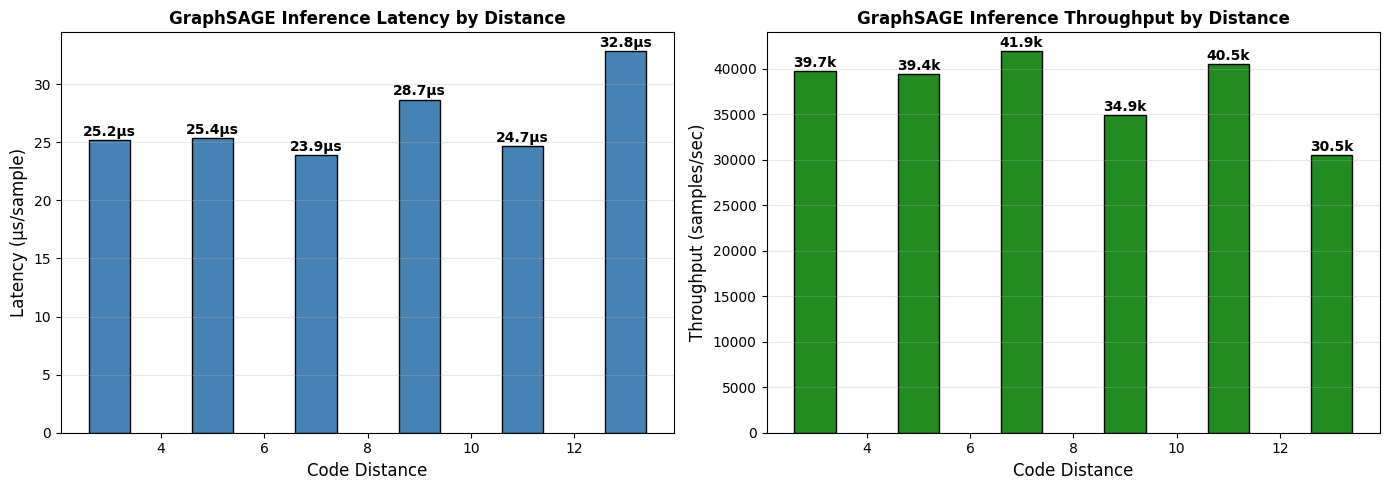


Plot saved to: inference_benchmark.png


In [32]:
# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

latencies = [results[d]['latency_us'] for d in DISTANCES]
throughputs = [results[d]['throughput'] for d in DISTANCES]

# Plot 1: Latency by distance
ax = axes[0]
bars = ax.bar(DISTANCES, latencies, color='steelblue', edgecolor='black')
ax.set_xlabel('Code Distance', fontsize=12)
ax.set_ylabel('Latency (µs/sample)', fontsize=12)
ax.set_title('GraphSAGE Inference Latency by Distance', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, lat in zip(bars, latencies):
    ax.annotate(f'{lat:.1f}µs', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

# Plot 2: Throughput by distance
ax = axes[1]
bars = ax.bar(DISTANCES, throughputs, color='forestgreen', edgecolor='black')
ax.set_xlabel('Code Distance', fontsize=12)
ax.set_ylabel('Throughput (samples/sec)', fontsize=12)
ax.set_title('GraphSAGE Inference Throughput by Distance', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, tput in zip(bars, throughputs):
    ax.annotate(f'{tput/1000:.1f}k', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('inference_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: inference_benchmark.png")

In [33]:
# Save results to CSV
results_data = []
for d in DISTANCES:
    r = results[d]
    results_data.append({
        'distance': d,
        'latency_us': round(r['latency_us'], 2),
        'throughput': round(r['throughput']),
        'batch_time_ms': round(r['mean_batch_ms'], 3),
        'batch_time_std_ms': round(r['std_batch_ms'], 3),
    })

results_df = pd.DataFrame(results_data)
results_df.to_csv('inference_benchmark.csv', index=False)
print("\nResults saved to: inference_benchmark.csv")
print(results_df.to_string(index=False))


Results saved to: inference_benchmark.csv
 distance  latency_us  throughput  batch_time_ms  batch_time_std_ms
        3       25.19       39702          1.612              0.272
        5       25.37       39416          1.624              0.338
        7       23.87       41890          1.528              0.163
        9       28.68       34866          1.836              0.510
       11       24.68       40515          1.580              0.176
       13       32.82       30468          2.101              0.270


In [34]:
# Benchmark OLD method (for-loop)
def old_pooling(x, batch, batch_size):
    x_pooled = torch.zeros(batch_size, x.size(1), device=x.device)
    for i in range(batch_size):
        mask = (batch == i)
        if mask.sum() > 0:
            x_pooled[i] = x[mask].mean(dim=0)
    return x_pooled

# Benchmark NEW method (global_mean_pool)
def new_pooling(x, batch):
    return global_mean_pool(x, batch)

NUM_ITER = 100

# OLD method
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(NUM_ITER):
    _ = old_pooling(x, batch, BATCH_SIZE)
torch.cuda.synchronize()
old_time = (time.perf_counter() - t0) * 1000 / NUM_ITER

# NEW method
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(NUM_ITER):
    _ = new_pooling(x, batch)
torch.cuda.synchronize()
new_time = (time.perf_counter() - t0) * 1000 / NUM_ITER

print(f"Pooling comparison (d={d}, batch_size={BATCH_SIZE}):")
print(f"  OLD (for-loop):       {old_time:.3f} ms")
print(f"  NEW (global_mean_pool): {new_time:.3f} ms")
print(f"  Speedup: {old_time/new_time:.1f}x")

AttributeError: 'bool' object has no attribute 'sum'

In [ ]:
# Verify outputs are the same
old_result = old_pooling(x, batch, BATCH_SIZE)
new_result = new_pooling(x, batch)

diff = (old_result - new_result).abs().max().item()
print(f"Max difference between methods: {diff:.2e}")
print(f"Results match: {diff < 1e-5}")

Max difference between methods: 9.54e-07
Results match: True
